In [1]:
#train pipleline


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [3]:
N_BINS = 80

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)


In [4]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [5]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [6]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [7]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [8]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [18]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
    threshold_percentile=95,
):
    """
    Compute activity maps for one neuron.

    Only the strongest activations contribute to the map.
    """

    # D4 is already after LeakyReLU
    amplitude = np.asarray(activity).copy()

    # Keep only strongest activations
    threshold = np.percentile(
        amplitude,
        threshold_percentile,
    )

    amplitude[amplitude < threshold] = 0

    real = amplitude.copy()

    amplitude_activity = np.zeros((bins, bins), dtype=float)
    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        if a > 0:

            amplitude_activity[yb, xb] += a
            real_activity[yb, xb] += r

    return (
        amplitude_activity,
        real_activity,
    )

In [19]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [20]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

In [21]:
def spatial_information(rate_map, occupancy_map):
    """
    Spatial Information (bits/spike)

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map

    occupancy_map : ndarray
        Count or probability occupancy
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
        & (rate_map > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    r_bar = np.sum(p * r)

    if r_bar <= EPS:
        return np.nan

    ratio = r / r_bar

    return np.sum(
        p * ratio * np.log2(ratio)
    )

In [22]:
def sparsity(rate_map, occupancy_map):
    """
    Population sparsity
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r**2)

    if mean_r2 <= EPS:
        return np.nan

    return (mean_r**2) / mean_r2

In [23]:
def evaluate_place_cell(rate_map, occupancy_map):
    """
    Compute place-cell metrics from a raw firing-rate map.
    """

    return {
        "Spatial Information": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

#main


In [24]:
import pickle
import numpy as np

layer_name = "d4"

trajectory_results_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    layer_name,
)

In [25]:
print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [26]:
positions_all = positions.reshape(-1, 2)

activations_all = activations.reshape(
    -1,
    activations.shape[-1]
)

print("Combined positions :", positions_all.shape)
print("Combined activations:", activations_all.shape)

Combined positions : (225000, 2)
Combined activations: (225000, 100)


In [27]:
bounds = (
    positions_all[:,0].min(),
    positions_all[:,0].max(),
    positions_all[:,1].min(),
    positions_all[:,1].max(),
)

print(bounds)

(0.027809273, 0.96892226, 0.029556997, 0.9583375)


In [28]:
x_bin, y_bin, x_edges, y_edges = bin_positions(
    positions_all,
    bins=N_BINS,
    bounds=bounds,
)

In [29]:
count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

print(count_occ.shape)
print(count_occ.sum())

(80, 80)
225000.0


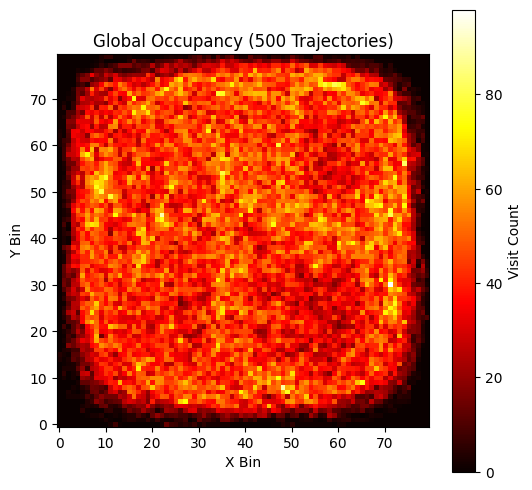

In [30]:
plt.figure(figsize=(6,6))

plt.imshow(
    count_occ,
    origin="lower",
    cmap="hot",
)

plt.title("Global Occupancy (500 Trajectories)")
plt.colorbar(label="Visit Count")

plt.xlabel("X Bin")
plt.ylabel("Y Bin")

plt.show()

In [31]:
# ==========================================================
# Compute firing maps for ALL neurons
# ==========================================================

all_results = []

n_neurons = activations_all.shape[1]

print(f"Processing {n_neurons} neurons...")

for neuron in range(n_neurons):

    activity = activations_all[:, neuron]

    # Activity maps
    amp_activity, real_activity = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
    )

    # Firing-rate maps
    amp_count = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    amp_prob = compute_firing_rate_map(
        amp_activity,
        prob_occ,
    )

    real_count = compute_firing_rate_map(
        real_activity,
        count_occ,
    )

    real_prob = compute_firing_rate_map(
        real_activity,
        prob_occ,
    )

    # Smooth maps
    amp_count_s = smooth_firing_rate_map(amp_count)

    amp_prob_s = smooth_firing_rate_map(amp_prob)

    real_count_s = smooth_firing_rate_map(real_count)

    real_prob_s = smooth_firing_rate_map(real_prob)

    all_results.append({

        "Neuron": neuron,

        "amp_count": amp_count_s,

        "amp_prob": amp_prob_s,

        "real_count": real_count_s,

        "real_prob": real_prob_s,

    })

print(f"Finished {len(all_results)} neurons.")

Processing 100 neurons...
Finished 100 neurons.


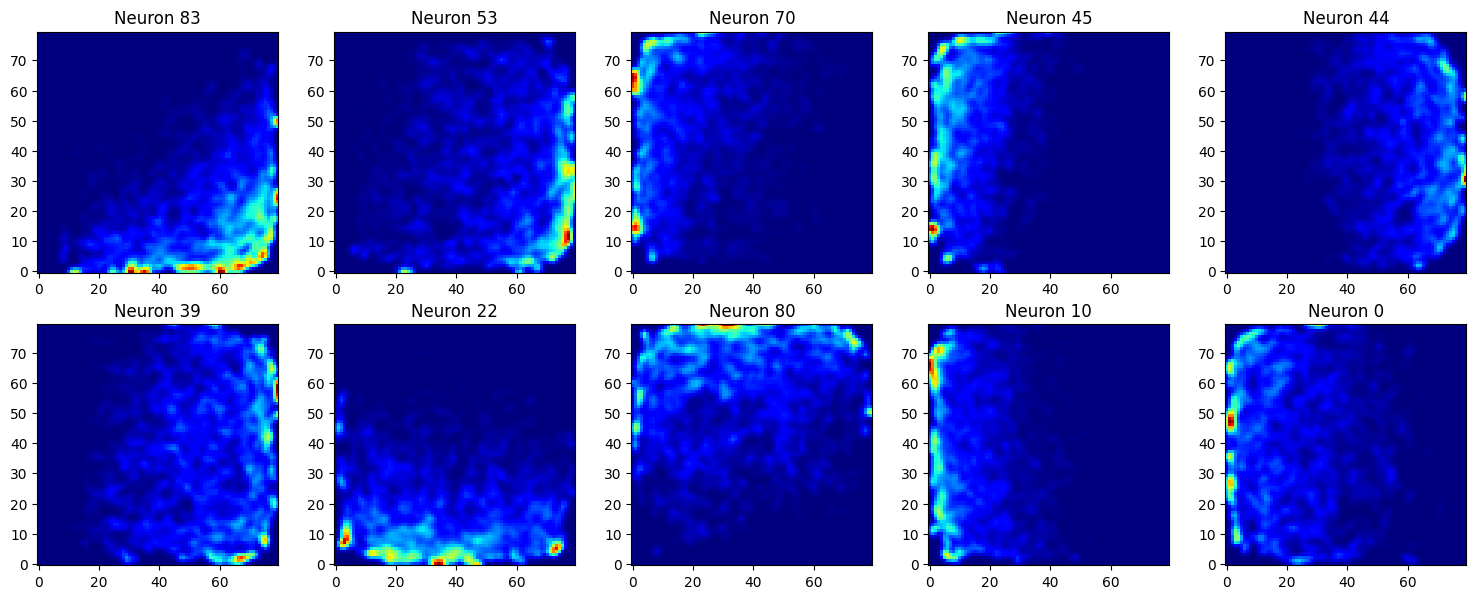

In [32]:
# ==========================================================
# Plot 10 random neurons
# ==========================================================

np.random.seed(42)

neurons = np.random.choice(
    len(all_results),
    10,
    replace=False,
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, neuron in zip(axes.flat, neurons):

    im = ax.imshow(
        all_results[neuron]["amp_count"],
        origin="lower",
        cmap="jet",
    )

    ax.set_title(f"Neuron {neuron}")

plt.tight_layout()

plt.show()

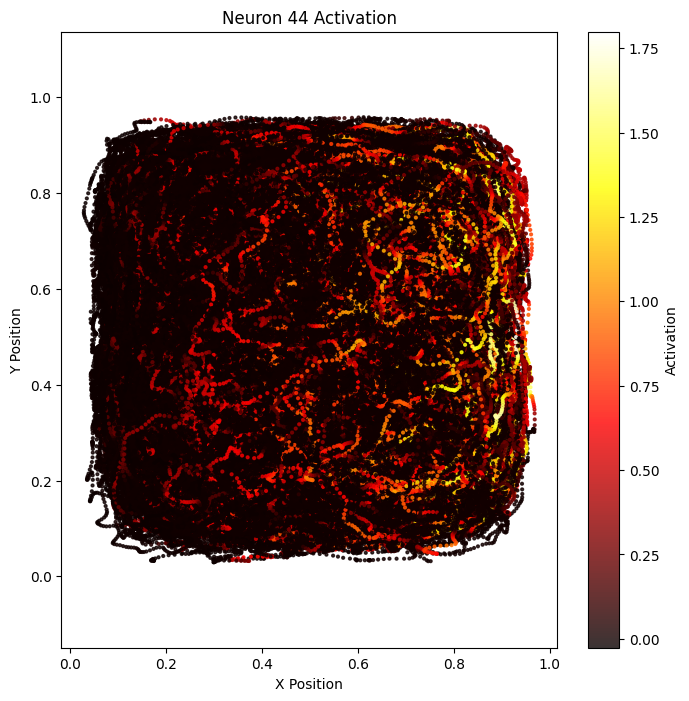

In [33]:
# ==========================================================
# Plot neuron activity over the environment
# ==========================================================

neuron = 44

activity = activations_all[:, neuron]

plt.figure(figsize=(8,8))

plt.scatter(
    positions_all[:,0],
    positions_all[:,1],
    c=activity,
    s=4,
    cmap="hot",
    alpha=0.8,
)

plt.colorbar(label="Activation")

plt.title(f"Neuron {neuron} Activation")

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.axis("equal")

plt.show()

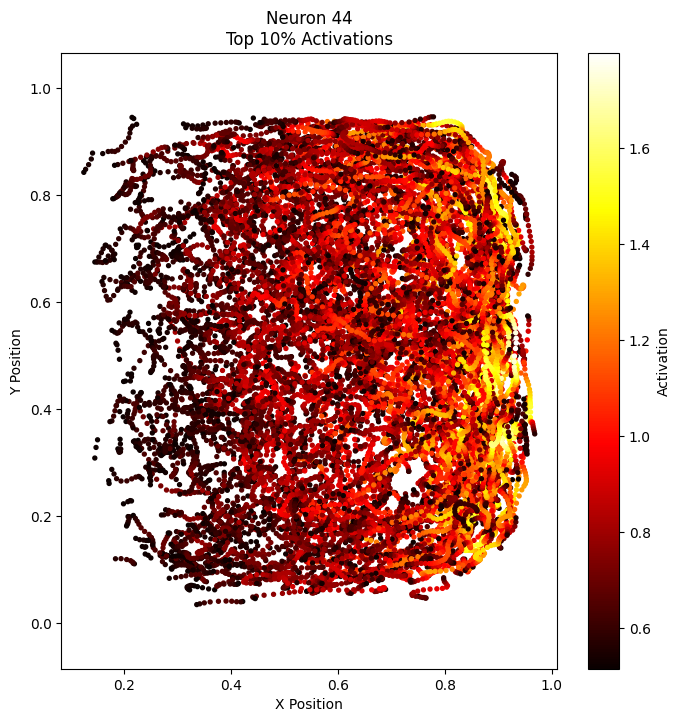

In [34]:
# ==========================================================
# Plot only strongest activations
# ==========================================================

neuron = 44

activity = activations_all[:, neuron]

threshold = np.percentile(activity, 90)

mask = activity >= threshold

plt.figure(figsize=(8,8))

plt.scatter(
    positions_all[mask,0],
    positions_all[mask,1],
    c=activity[mask],
    s=8,
    cmap="hot",
)

plt.colorbar(label="Activation")

plt.title(
    f"Neuron {neuron}\nTop 10% Activations"
)

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.axis("equal")

plt.show()

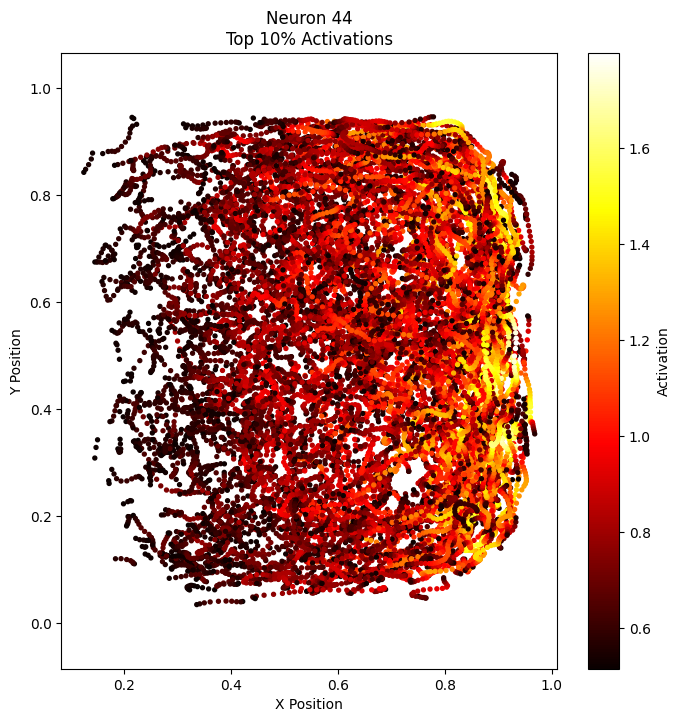

In [35]:
# ==========================================================
# Plot only strongest activations
# ==========================================================

neuron = 44

activity = activations_all[:, neuron]

threshold = np.percentile(activity, 90)

mask = activity >= threshold

plt.figure(figsize=(8,8))

plt.scatter(
    positions_all[mask,0],
    positions_all[mask,1],
    c=activity[mask],
    s=8,
    cmap="hot",
)

plt.colorbar(label="Activation")

plt.title(
    f"Neuron {neuron}\nTop 10% Activations"
)

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.axis("equal")

plt.show()

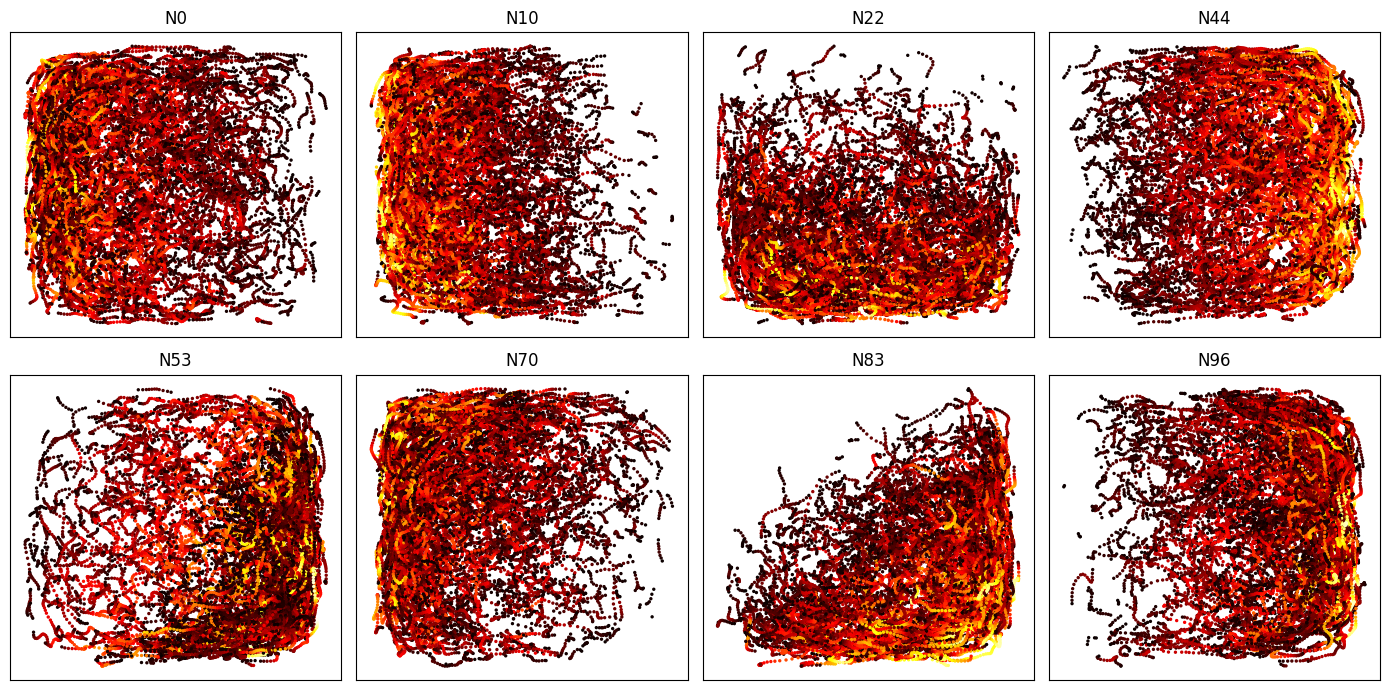

In [36]:
# ==========================================================
# Compare several neurons
# ==========================================================

neurons = [0,10,22,44,53,70,83,96]

fig, axes = plt.subplots(2,4, figsize=(14,7))

for ax, neuron in zip(axes.flat, neurons):

    activity = activations_all[:, neuron]

    threshold = np.percentile(activity,90)

    mask = activity >= threshold

    ax.scatter(
        positions_all[mask,0],
        positions_all[mask,1],
        c=activity[mask],
        s=2,
        cmap="hot",
    )

    ax.set_title(f"N{neuron}")

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()